# Introduction

The following notebook is meant to give an overview of code related to simulated behaviour on the 2-armed bandit reversal learning task.

1. Overview of coded task (NM_TinyRNN/code/simulations/reversal_2ab.py) 
2. Bayes optimal solution (NM_TinyRNN/code/simulations/reversal_2ab.py)
3. q-learning model fits (NM_TinyRNN/code/models/qlearning.py)
4. rnn model fits (NM_TinyRNN/code/models/rnns.py + other scripts)



## ReversalTask

The reversal learning task is coded to be similar to the task structure experienced by mice.

>**NOTE**: here the task progresses with task-states similar to what the mice experience: 
>
>initiate -> choice -> outcome -> (...repeat)
>
>This is in contrast to the single trial-by-trial modelling that we perform, where timepoints are collapsed such that we ignore initiation actions and simply consider models as functions which predict upcoming choices: $$f(\text{choice}_{t},\text{outcome}_t,\text{modelState}_t) = \text{choice}_{t+1}.$$
>>

The mice see three ports, corresponding to three accepted actions: 
`initiate`, `left`, and `right`.

The initiation port is in the center and cued by the observation `[1,0,0]`.
Only an `initiate` action will move the task to the next state.
This is either a free choice, cued by `[0,1,1]`, or a forced choice, cued by `[0,1,0]` or `[0,0,1]`. 
During a forced choice, only the correct `left` or `right` action will update the task state, while either action will work during free choices.

The `reward outcome` is either `0` or `1`, and is `1` at a probabilistic rate, with 75% chance of being rewarded on the `good_side` and 25% chance of being rewarded on the other side. 
This `good_side` is a hidden state that must be inferred by the mice. The side also switches when the mouse reaches a reward rate of 75% on free choices, calculated with an exponential moving average with tau=8. 

This has been coded up as the `ReversalTask` class in `NM_TinyRNN/code/simulations/reversal_2ab.py`

In [ ]:
from NM_TinyRNN.code.simulations import reversal_2ab as rab
# play task manually! (Check for bugs)
task = rab.ReversalTask()

rewards = 0
for i in range(10):
  action = input("Action (0: initiate, 1:left, 2:right) = ")
  obs, reward, info = task.step(int(action))
  print(f"Observation:{obs}, reward:{reward}", flush=True)
  rewards+=reward
print(f'DONE total rewards={rewards}')

Action (0: initiate, 1:left, 2:right) = 0
Observation:[0. 0. 1.], reward:0.0
Action (0: initiate, 1:left, 2:right) = 2
Observation:[1. 0. 0.], reward:0.0
Action (0: initiate, 1:left, 2:right) = 0
Observation:[0. 0. 1.], reward:0.0
Action (0: initiate, 1:left, 2:right) = 2
Observation:[1. 0. 0.], reward:0.0
Action (0: initiate, 1:left, 2:right) = 0
Observation:[0. 1. 1.], reward:0.0
Action (0: initiate, 1:left, 2:right) = 1
Observation:[1. 0. 0.], reward:1.0
Action (0: initiate, 1:left, 2:right) = 0
Observation:[0. 1. 0.], reward:0.0
Action (0: initiate, 1:left, 2:right) = 1
Observation:[1. 0. 0.], reward:1.0
Action (0: initiate, 1:left, 2:right) = 0
Observation:[0. 1. 1.], reward:0.0
Action (0: initiate, 1:left, 2:right) = 1
Observation:[1. 0. 0.], reward:1.0
DONE total rewards=3.0


## An optimal solution to the reversal task

If we know the structure of the task, we can model it at the level of every choice (ignoring initation). This can be modelled as a partially observable markov decision process (POMDP), where for every trial, $t\in \mathbb{N}$, an agent makes an action, $a_t$, sees an observation (reward outcome), $o_t$, updates its belief, $b_t$, and then repeats:
$$ a_t \to o_t \to b_t\to a_{t+1} \to o_{t+1} \to b_{t+1} \to \cdots. $$
Here the observations (reward outcomes) depend on the action taken (left or right) as well as the hidden state of the world (which side is good) - hence partial observability about the states of the world.

This has been studied extensively and we refer to Kaelbling et al. 1998 for a general introduction to POMDPs and belief states. 

The main take-away is that POMDPs can be solved by a state estimator. In this case we want to know the probability that the left side is good ($s_t=L$) or that the right side is good ($s_t=R$). Importantly, we need to infer the current state given a history of actions and observations, which we denote $\mathcal{H}_t:= (a_{1:t},o_{1:t})$. Now we can use our knowledge of the task to derive an optimal state estimator. 

We know that there can be two states (left good or right good), that rewards occur with 75% probability for actions on the good side and 25% for actions on the bad side. We can also estimate that a switch happens after 19 trials on the correct side (see below).

We want our belief about the world state $b_t$ to coincide with the exact probability that the left side is good (without loss of generality, since we can then infer the probability that the right side is good).

$$b_t = P(s_t=L\mid \mathcal{H}_t)$$

It turns out that because our task is markov (the next state depends only on the current state), we can get away with simply updating our belief state recursively. The derivation of this algorithm uses bayes rule with respect to the observation $o_t$:

\begin{align} b_{t}& = P(s_t=L\mid a_t,o_t,b_{t-1}) \\
                    & = \frac{P(o_t\mid s_t=L, a_t, b_{t-1})\cdot P(s_t=L\mid a_t, b_{t-1})}{P(o_t\mid a_t, b_{t-1})}\\
                    & = \frac{P(o_t\mid s_t=L, a_t, b_{t-1})\cdot \hat{b}_{t}}{P(o_t\mid s_t=L, a_t)\cdot \hat{b}_{t}+P(o_t\mid s_t\ne L, a_t)\cdot (1-\hat{b}_{t})}
 \end{align}

 where $\hat{b}_{t}$ denotes the prior probability that the left side is good after taking action $a_t$ and observing $o_t$ in trial $t$, which accounts for the reversal probability $p$:

 $$\hat{b}_{t} = P(s_t=L\mid a_t, b_{t-1}) = (1-p)\cdot b_{t-1} + p\cdot (1-b_{t-1}).$$

The exact probabilities in equation $(3)$ can be solved using our knowledge about the task.

 > **NOTE:** 
 > the task is coded with generative structure
 > action --> observation --> [reversal?]
 > 
 > so the action at time $t+1$ should be predicted from $\hat{b}_{t+1}$, as this accounts for the likelihood of a reversal since the last observation. With reference to Ji-An et al., 2025, their equation (5) is similar to equation (3) here, noting the following differences in notations:
 >| Ji-An et al., 2025 | here | Role |
>|---|---|---|
>| $\Pr_{t-1}(h=1)$ | $\hat{b}_{t-1}$ | Prior entering trial $t-1$ (post-reversal) |
>| $\overline{\Pr_t(h=1)}$ | $b_{t-1}$ | Posterior after observing trial $t-1$'s outcome |
>| $\Pr_t(h=1)$ | $\hat{b}_t$ | Prior entering trial $t$ (post-reversal, basis for action) |

In [ ]:
# Estimating the number of trials to reach the 0.75 EMA threshold when always choosing the correct side
import numpy as np
n_simulations = 10000
n_trials = []
for _ in range(n_simulations):
    ema = 0
    ema_tau = 8
    trial_count = 0
    while ema<0.75:
        trial_count += 1
        #suppose we always choose the correct side,
        #reward is 1 with 0.75 probability and 0 with 0.25 probability
        reward = 1 if np.random.rand() < 0.75 else 0
        ema = (1 - 1/ema_tau) * ema + (1/ema_tau) * reward
        
    n_trials.append(trial_count)
print(f'EMA: {ema}, Trials: {trial_count}')
np.quantile(n_trials, [0.25, 0.5, 0.75])

EMA: 0.7676605019241833, Trials: 13


array([15., 19., 25.])

<Axes: xlabel='logit_value', ylabel='logit_change'>

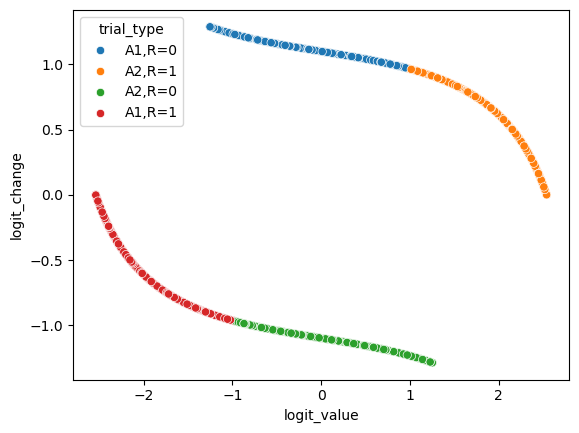

In [ ]:
# Code to simulate a bayesian agent on the reversal task
from NM_TinyRNN.code.simulations.reversal_2ab import simulate, BayesAgent

trials_df = simulate(n_episodes = 10, n_trials = 500, 
                     agent_class=BayesAgent)

#We will visualise this as a 'logit_plot'

def logit_plot(trials_df, title="", ax = None):
    import matplotlib.pyplot as plt
    import seaborn as sns
    # Plotting
    if ax == None:
        fig, ax = plt.subplots(figsize=(3,3))
    palette = sns.color_palette("coolwarm", n_colors=4)
    palette[[0,3]] = palette [[3,0]]  # Swap the first and last colors
    sns.scatterplot(trials_df,
                    x='logit_value', y = 'logit_change',
                    hue = 'trial_type',palette=palette,
                    ax=ax)
    ax.axhline(0, color='grey', linestyle='--')  # Add a horizontal line at log-odds = 0 (p=0.5)
    ax.set(xlabel= 'Logit',ylabel = 'Logit change', title = title)#
    ax.axis('square')
    return ax

plot = logit_plot(trials_df)


A1,R=0: n=636, unique x=633
A1,R=0: slope range [-0.23, -0.11]
A1,R=1: n=1246, unique x=1236
A1,R=1: slope range [-1.71, -0.26]
A2,R=0: n=634, unique x=632
A2,R=0: slope range [-0.23, -0.11]
A2,R=1: n=1217, unique x=1211
A2,R=1: slope range [-1.70, -0.25]


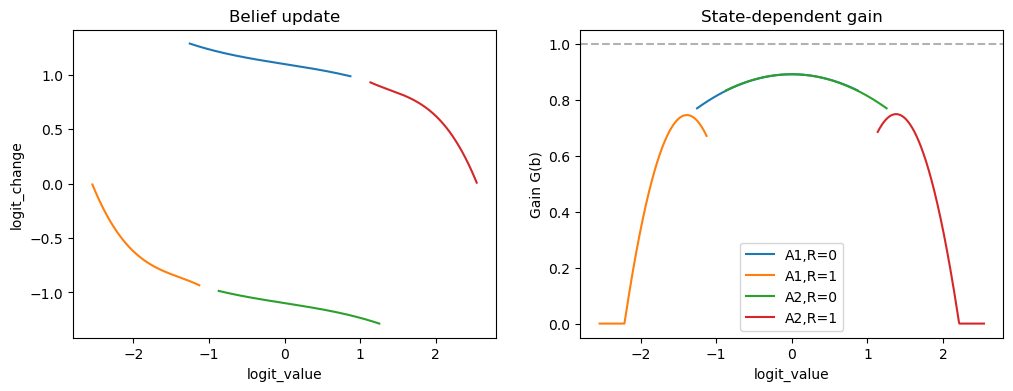

In [76]:
from scipy.interpolate import UnivariateSpline
from numpy.polynomial import polynomial as P

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for trial_type, group in trials_df.query('forced_choice==0').groupby('trial_type'):
    sorted_group = group.sort_values('logit_value').dropna(subset=['logit_value', 'logit_change'])
    x = sorted_group['logit_value'].values
    y = sorted_group['logit_change'].values
    # Only fit and evaluate over the central data range
    quantile_low, quantile_high = 0.05, 0.95
    x_min = np.quantile(x, quantile_low)
    x_max = np.quantile(x, quantile_high)

    
    
    # Diagnose
    print(f"{trial_type}: n={len(x)}, unique x={len(np.unique(x))}")
    
    if len(np.unique(x)) < 4:
        print(f"  Skipping {trial_type} - insufficient unique x values")
        continue
    
    x_dense = np.linspace(x_min, x_max, 200)

    
    try:
        # Also increase smoothing to reduce boundary overfitting
        spline = UnivariateSpline(x, y, s=len(x) * 2)
        y_fit = spline(x_dense)
        # After computing gain per trial type...
        slope = spline.derivative()(x_dense)

        print(f"{trial_type}: slope range [{slope.min():.2f}, {slope.max():.2f}]")
        # Should always be within (-1, 0) if spline is well-behaved
        # Values outside this range are boundary artifacts

        # Clip gain to theoretically valid range as a diagnostic
        gain = np.clip(slope + 1, 0, 1)
        #gain = spline.derivative()(x_dense) + 1
    except Exception as e:
        print(f"  Spline failed for {trial_type}: {e}, falling back to polynomial")
        # Fallback: degree-3 polynomial fit
        coeffs = np.polyfit(x, y, deg=3)
        poly = np.poly1d(coeffs)
        y_fit = poly(x_dense)
        gain = np.polyder(poly)(x_dense) + 1
    
    axes[0].plot(x_dense, y_fit, label=trial_type)
    axes[1].plot(x_dense, gain, label=trial_type)

axes[0].set(xlabel='logit_value', ylabel='logit_change', title='Belief update')
axes[1].set(xlabel='logit_value', ylabel='Gain G(b)', title='State-dependent gain')
axes[1].axhline(1, color='k', linestyle='--', alpha=0.3)
plt.legend()